/tmp/ipykernel_9196/2737899560.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yk = float(C @ x_full[:, k])
/tmp/ipykernel_9196/2737899560.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  uk = float(K @ xhat_full[:, k])
/tmp/ipykernel_9196/2737899560.py:48: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat_k = float(C @ xhat_full[:, k])
/tmp/ipykernel_9196/2737899560.py:56: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated

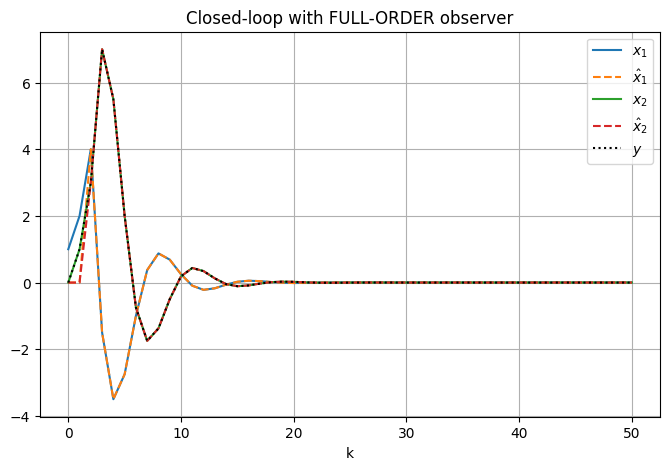

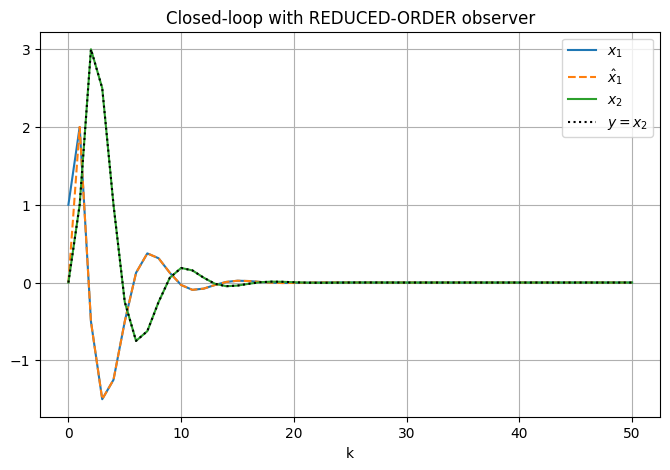

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([[2.0, 0.0],
              [1.0, 1.0]])
B = np.array([[1.0],
              [0.0]])
C = np.array([[0.0, 1.0]])

K = np.array([[-2.0, -0.5]])      
L = np.array([[4.0],
              [3.0]])             

N = 50
x0 = np.array([1.0, 0.0])         
xhat0_full = np.array([0.0, 0.0]) 
xhat1_0 = 0.0                     

x_full = np.zeros((2, N+1))
xhat_full = np.zeros((2, N+1))
y_full = np.zeros(N+1)
u_full = np.zeros(N)

x_full[:, 0] = x0
xhat_full[:, 0] = xhat0_full

for k in range(N):
    yk = float(C @ x_full[:, k])
    y_full[k] = yk

    uk = float(K @ xhat_full[:, k])
    u_full[k] = uk

    x_full[:, k+1] = A @ x_full[:, k] + (B * uk).reshape(2)

    yhat_k = float(C @ xhat_full[:, k])
    xhat_full[:, k+1] = (
        A @ xhat_full[:, k]
        + (B * uk).reshape(2)
        + (L * (yk - yhat_k)).reshape(2)
    )

y_full[N] = float(C @ x_full[:, N])

x_red = np.zeros((2, N+1))
xhat1 = np.zeros(N+1)      
y_red = np.zeros(N+1)
u_red = np.zeros(N)

x_red[:, 0] = x0
xhat1[0] = xhat1_0

for k in range(N):
    yk = x_red[1, k]
    y_red[k] = yk

    uk = float(K @ np.array([xhat1[k], yk]))
    u_red[k] = uk

    x_red[:, k+1] = A @ x_red[:, k] + (B * uk).reshape(2)

    yk1 = x_red[1, k+1]            
    hat_y_pred = yk + xhat1[k]     
    xhat1[k+1] = 2 * xhat1[k] + uk + 2 * (yk1 - hat_y_pred)

y_red[N] = x_red[1, N]

k = np.arange(N+1)

plt.figure(figsize=(8, 5))
plt.title("Closed-loop with FULL-ORDER observer")
plt.plot(k, x_full[0, :], label=r"$x_1$")
plt.plot(k, xhat_full[0, :], "--", label=r"$\hat{x}_1$")
plt.plot(k, x_full[1, :], label=r"$x_2$")
plt.plot(k, xhat_full[1, :], "--", label=r"$\hat{x}_2$")
plt.plot(k, y_full, "k:", label=r"$y$")
plt.xlabel("k")
plt.legend()
plt.grid(True)

plt.figure(figsize=(8, 5))
plt.title("Closed-loop with REDUCED-ORDER observer")
plt.plot(k, x_red[0, :], label=r"$x_1$")
plt.plot(k, xhat1, "--", label=r"$\hat{x}_1$")
plt.plot(k, x_red[1, :], label=r"$x_2$")
plt.plot(k, y_red, "k:", label=r"$y = x_2$")
plt.xlabel("k")
plt.legend()
plt.grid(True)

plt.show()
